## 도구 연동 연습 - Tavily 검색 도구를 활용한 제조 도메인 챗봇

목표
- Tavily Search API를 활용한 검색 도구를 그래프에 통합합니다.
- 도구 호출 조건부 라우팅을 구현하여 검색이 필요한 경우 자동으로 도구를 사용합니다.
- 제조업 관련 정보(스마트 팩토리, 산업 자동화 등)를 검색하고 답변하는 챗봇을 구축합니다.

요구사항
- `TavilySearch` 도구를 설정하고 LLM에 바인딩합니다.
- 도구 호출이 필요한 경우 `tools` 노드로, 아니면 종료하는 조건부 라우팅을 구현합니다.
- START → chatbot → 조건부 라우팅 → tools/END 경로를 구성합니다.
- 제조업 관련 질문으로 테스트하여 검색 결과가 올바르게 반환되는지 확인합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

load_dotenv(override=True)

# 프로젝트 이름
logging.langsmith("LangGraph-Tool-Integration")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-Tool-Integration


In [2]:
# 준비 코드
from typing import Annotated
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

### 1. State 및 LLM 모델 정의

- `State` TypedDict에 `messages: Annotated[list, add_messages]`를 정의하세요.
- ChatOpenAI 모델을 생성하세요. (model="gpt-4o-mini", temperature=0)

In [ ]:
# 실습 코드
# TODO: State 클래스를 정의하세요.
class State(TypedDict):
    messages: Annotated[list, add_messages] # 코드 입력

# TODO: LLM 모델을 생성하세요.
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0) # 코드 입력

### 2. Tavily 검색 도구 설정

- TavilySearch 도구를 생성하세요. (max_results=3)
- 도구를 리스트로 만들고 LLM에 바인딩하세요.
- 간단한 테스트로 "스마트 팩토리 최신 동향"을 검색해보세요.

In [4]:
# 실습 코드
# TODO: Tavily 검색 도구를 생성하세요.
tavily_tool = TavilySearch(max_results=3) # 코드 입력
tools = [tavily_tool] # 코드 입력

# TODO: LLM에 도구를 바인딩하세요.
llm_with_tools = llm.bind_tools(tools) # 코드 입력

# TODO: 도구 테스트 - "스마트 팩토리 최신 동향" 검색
test_result = tavily_tool.invoke("스마트 팩토리 최신 동향") # 코드 입력
print(f"검색 결과 수: {len(test_result['results'])}개")

검색 결과 수: 3개


### 3. Chatbot 노드 구현

- 도구가 바인딩된 LLM을 사용하여 chatbot 노드를 구현하세요.
- state의 messages를 받아 응답을 반환합니다.
- 반환 형식은 {"messages": [response]} 입니다.

In [5]:
# 실습 코드
# TODO: chatbot 노드를 구현하세요.
def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"]) # 코드 입력
    return {"messages": response} # 코드 입력

### 4. 그래프 구성 및 조건부 라우팅

- StateGraph를 생성하고 노드들을 추가하세요.
- chatbot 노드와 ToolNode를 추가합니다.
- chatbot에서 조건부 라우팅을 설정합니다 (tools_condition 사용).
- tools 노드는 다시 chatbot으로 연결됩니다.

In [9]:
# 실습 코드
# TODO: 그래프를 구성하세요.
builder = StateGraph(State) # 코드 입력

# TODO: 노드들을 추가하세요.
builder.add_node("chatbot", chatbot) # 코드 입력)
builder.add_node("tools", ToolNode(tools))  # 코드 입력)

# TODO: 엣지를 추가하세요.
builder.add_edge(START, "chatbot") # 코드 입력)
builder.add_conditional_edges("chatbot", tools_condition) # 코드 입력) # tools와 end로 가는 tools
builder.add_edge("tools", "chatbot") # 코드 입력)

# TODO: 그래프를 컴파일하세요.
app = builder.compile() # 코드 입력

### 5. 그래프 시각화 및 실행

- 컴파일된 그래프를 시각화하세요.
- 제조업 관련 질문으로 그래프를 실행하고 결과를 확인하세요.
- 예시: "한국의 산업용 로봇 시장 현황과 주요 기업은?"

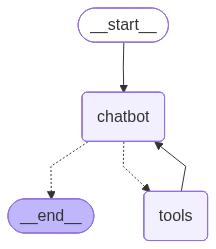

In [10]:
# 실습 코드
# TODO: 그래프를 시각화하세요.
from langchain_teddynote.graphs import visualize_graph

# 코드 입력
# visualize_graph(app)
app

In [13]:
# 실습 코드
# TODO: 제조업 관련 질문으로 실행하세요.
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(recursion_limit=10)

inputs = {
    "messages": [HumanMessage(content="한국의 산업용 로봇 시장 현황과 주요 기업은?")
        # 코드 입력: HumanMessage로 질문 작성
    ]
}

# 코드 입력: stream_graph로 실행
stream_graph(app, inputs=inputs, config=config)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "한국 산업용 로봇 시장 현황 주요 기업", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.globalresearch.co.kr/insight/industrial-robotics-market-imarc/", "title": "한국의 산업용 로봇 시장: 시장규모, 점유율, 예측 (2025년-2033년)", "content": "한국의 산업용 로봇 시장은 고도로 자동화된 전자 및 자동차 부문의 수요에 크게 견인되고 있습니다. 삼성, 현대, LG와 같은 주요 기업들은 생산의 정확성, 속도 및 효율성 향상을 위해 로봇 공학을 활용한 자동화에 크게 의존하고 있습니다. 전 세계적인 경쟁이 심화됨에 따라 제조업체들은 생산성 향상, 오류율 감소 및 인건비 절감을 위해 로봇을 도입하고 있습니다. 마이크로 조립, PCB 생산, 용접, 도장 작업을 수행할 수 있는 로봇에 대한 수요는 지속적으로 증가하고 있다. 특히 반도체 생산과 같은 클린룸 환경에서 사용 가능한 로봇도 이 산업군에서 필수적이다. 제품 복잡성 증가와 품질 요구사항 강화로 인해 생산 목표 달성과 한국이 글로벌 전자·자동차 공급망에서 경쟁력을 유지하기 위해 산업용 로봇의 중요성은 더욱 커지고 있다.\n\n강력한 정부 지원과 스마트 공장 추진 [...] 2.1 연구 목적\n\n2.2 관계자\n\n2.3 데이터 출처\n\n2.3.1 1차 자료\n\n2.3.2 2차 자료\n\n2.4 시장 추정\n\n2.4.1 상향식 접근법\n\n2.4.2 하향식 접근법\n\n2.5 예측 방법론\n\n3 요약\n\n4 한국 산업용 로봇 시장 – 개요\n\n4.1 개

아래의 코드를 실행하여 결과를 확인하세요

In [ ]:
# 정답 코드
# TODO: 제조업 관련 질문으로 실행하세요.
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(recursion_limit=10)

inputs = {
    "messages": [HumanMessage(content="한국의 산업용 로봇 시장 현황과 주요 기업은?")]
}

stream_graph(app, inputs=inputs, config=config)

### 추가 연습

다음 제조업 관련 질문들로 챗봇을 테스트해보세요:
- "스마트 팩토리 구축에 필요한 핵심 기술은?"
- "최신 제조업 자동화 트렌드와 AI 활용 사례는?"
- "글로벌 제조업 디지털 전환 성공 사례를 알려줘"